In [1]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression



#Linear Regression

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score



#Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report

#Cluster

from sklearn.cluster import KMeans

from scipy.spatial.distance import cdist
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import silhouette_samples
from sklearn.metrics import silhouette_score

In [2]:
url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

df = pd.read_csv(url)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# Análise de transações e fraudes

**Objetivo:** conhecer os dados e testar um modelo de classificação para identificar transações suspeitas. `Class = 0` representa transação legítima; `Class = 1`, fraude. Os gráficos usam tons de vermelho.

## 1. Visão geral dos dados

In [3]:
print(f"Linhas: {df.shape[0]:,} | Colunas: {df.shape[1]}")
print("Valores ausentes:", df.isna().sum().sum())
df[["Time", "Amount", "Class"]].describe().round(2)

Linhas: 284,807 | Colunas: 31
Valores ausentes: 0


,Time,Amount,Class
count,284807.00,284807.00,284807.00
mean,94813.86,88.35,0.00
std,47488.15,250.12,0.04
min,0.00,0.00,0.00
25%,54201.50,5.60,0.00
50%,84692.00,22.00,0.00
75%,139320.50,77.16,0.00
max,172792.00,25691.16,1.00


In [4]:
cores = ["#D9A3A8", "#A6192E"]
contagem = df["Class"].value_counts().sort_index()
percentual = df["Class"].value_counts(normalize=True).sort_index() * 100
resumo = pd.DataFrame({"Transações": contagem, "Percentual (%)": percentual.round(3)})
resumo.index = ["Legítima", "Fraude"]
display(resumo)

,Transações,Percentual (%)
Legítima,284315,99.827
Fraude,492,0.173


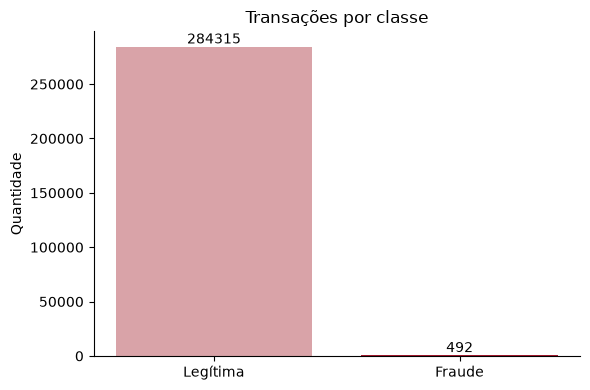

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
barras = ax.bar(resumo.index, resumo["Transações"], color=cores)
ax.bar_label(barras, fmt="%d")
ax.set(title="Transações por classe", ylabel="Quantidade")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 2. Valores das transações

Para manter o gráfico legível, mostramos os valores até o percentil 99 e usamos uma amostra de até 10 mil transações por classe. O treinamento abaixo usa todos os registros.

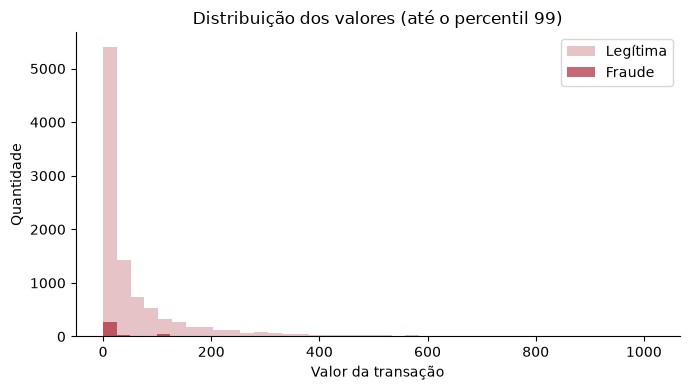

In [7]:
limite = df["Amount"].quantile(0.99)
amostra_grafico = pd.concat([
    grupo.sample(n=min(len(grupo), 10000), random_state=42)
    for _, grupo in df[df["Amount"] <= limite].groupby("Class")
])
fig, ax = plt.subplots(figsize=(7, 4))
for classe, rotulo, cor in [(0, "Legítima", cores[0]), (1, "Fraude", cores[1])]:
    ax.hist(amostra_grafico.loc[amostra_grafico["Class"] == classe, "Amount"],
            bins=40, alpha=0.65, label=rotulo, color=cor)
ax.set(title="Distribuição dos valores (até o percentil 99)", xlabel="Valor da transação", ylabel="Quantidade")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

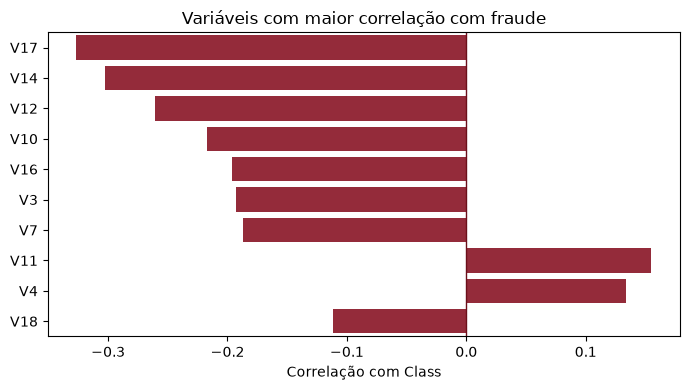

In [8]:
correlacoes = df.corr(numeric_only=True)["Class"].drop("Class")
principais = correlacoes.reindex(correlacoes.abs().sort_values(ascending=False).head(10).index)

plt.figure(figsize=(7, 4))
sns.barplot(x=principais.values, y=principais.index, color="#A6192E")
plt.axvline(0, color="#6B0F1A", linewidth=1)
plt.title("Variáveis com maior correlação com fraude")
plt.xlabel("Correlação com Class")
plt.ylabel("")
plt.tight_layout()
plt.show()

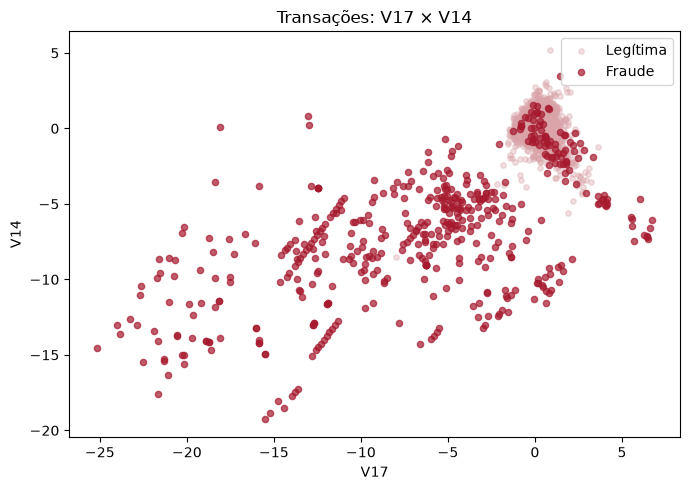

In [9]:
# Amostra para deixar o gráfico legível
legitimas = df[df["Class"] == 0].sample(n=2000, random_state=42)
fraudes = df[df["Class"] == 1]

plt.figure(figsize=(7, 5))

plt.scatter(
    legitimas["V17"], legitimas["V14"],
    color="#D9A3A8", alpha=0.35, s=15, label="Legítima"
)
plt.scatter(
    fraudes["V17"], fraudes["V14"],
    color="#A6192E", alpha=0.7, s=20, label="Fraude"
)

plt.title("Transações: V17 × V14")
plt.xlabel("V17")
plt.ylabel("V14")
plt.legend()
plt.tight_layout()
plt.show()

## 3. Modelo: regressão logística

Dividi os dados em treino (80%) e teste (20%), preservando a proporção de fraudes. A padronização é calculada apenas no treino. `class_weight="balanced"` dá maior peso aos exemplos da classe rara.

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

X = df.drop(columns="Class")
y = df["Class"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
modelo = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, class_weight="balanced"))
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)
print(f"Treino: {len(X_train):,} transações | Teste: {len(X_test):,} transações")

## 4. Avaliação do modelo

**Precision:** dentre as transações marcadas como fraude, quantas eram fraude? **Recall:** dentre as fraudes reais, quantas o modelo encontrou? **F1:** resume o equilíbrio entre precision e recall.

In [ ]:
metricas = pd.DataFrame({
    "Métrica": ["Acurácia", "Precision (fraude)", "Recall (fraude)", "F1 (fraude)"],
    "Resultado": [accuracy_score(y_test, y_pred),
                  precision_score(y_test, y_pred, zero_division=0),
                  recall_score(y_test, y_pred, zero_division=0),
                  f1_score(y_test, y_pred, zero_division=0)]
})
display(metricas.round(3))

In [ ]:
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds", cbar=False,
            xticklabels=["Legítima", "Fraude"],
            yticklabels=["Legítima", "Fraude"], ax=ax)
ax.set(title="Matriz de confusão", xlabel="Previsto pelo modelo", ylabel="Valor real")
plt.tight_layout()
plt.show()
print(f"Fraudes detectadas: {cm[1, 1]} | Fraudes não detectadas: {cm[1, 0]}")
print(f"Alertas falsos: {cm[0, 1]}")

## Conclusão

Compare **recall** (fraudes detectadas) com **precision** (alertas corretos) e examine os falsos negativos e falsos positivos na matriz. O resultado é um exercício didático: antes de usar um modelo para tomar decisões reais, seriam necessárias outras validações e uma escolha consciente do custo de cada tipo de erro.